<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana5/PCA_PLS_clase_mejorado_EJECUTADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning aplicado
## PCA y PLS: reducción de dimensión, visualización e interpretación

### Propósito de la actividad
En esta práctica estudiaremos **dos formas de construir nuevas variables a partir de predictores correlacionados**:

- **PCA (Principal Component Analysis):** encuentra direcciones que maximizan la variabilidad de $X$, **sin usar** la variable objetivo $y$.
- **PLS (Partial Least Squares):** construye componentes usando simultáneamente información de $X$ y su relación con $y$.

La idea central será pasar de una matriz de predictores $X$ a nuevas coordenadas $Z$ mediante una transformación lineal

$$
Z = XA,
$$

donde las columnas de $A$ definen nuevas direcciones del espacio de variables.

### Objetivos de aprendizaje
Al finalizar la práctica deberías poder:

1. Reconocer visualmente correlaciones y redundancia entre predictores.
2. Explicar geométricamente qué hace PCA.
3. Interpretar autovalores, varianza explicada y varianza acumulada.
4. Visualizar observaciones proyectadas en PC1–PC2 y PC1–PC2–PC3.
5. Interpretar los *loadings* para saber qué variables construyen cada componente.
6. Entender la diferencia entre **reducir dimensión** y **predecir mejor**.
7. Comparar PCR (regresión sobre componentes principales), PLS y regresión lineal.

> **Idea para la clase:** no ejecutar todo de una vez. Antes de cada gráfica, pedir a los estudiantes que predigan qué esperan observar.

## 1. Librerías y configuración

Usaremos únicamente librerías estándar del ecosistema científico de Python. Se fija una semilla para que la partición de entrenamiento y prueba sea reproducible.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 0
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

## 2. Carga de datos

Trabajaremos con la base **Diabetes** incluida en `scikit-learn`. Cada fila representa un paciente y la variable objetivo corresponde a una medida cuantitativa de progresión de la enfermedad un año después.

Las variables predictoras son:

- `age`: edad
- `sex`: sexo
- `bmi`: índice de masa corporal
- `bp`: presión arterial promedio
- `s1` a `s6`: seis mediciones séricas

Aunque este dataset ya viene centrado y escalado en su distribución original, **volveremos a estandarizar usando únicamente el conjunto de entrenamiento** para mantener el procedimiento general que se usaría con cualquier base de datos.

In [ ]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()
feature_names = list(diabetes.feature_names)
target_name = 'target'

print(f'Número de observaciones: {df.shape[0]}')
print(f'Número de predictores: {len(feature_names)}')
display(df.head())

Número de observaciones: 442
Número de predictores: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


## 3. Exploración visual antes de hacer PCA

PCA cobra sentido cuando existen variables que comparten información. Antes de aplicar el método, conviene **mirar los datos**.

### 3.1 Distribución de la variable objetivo

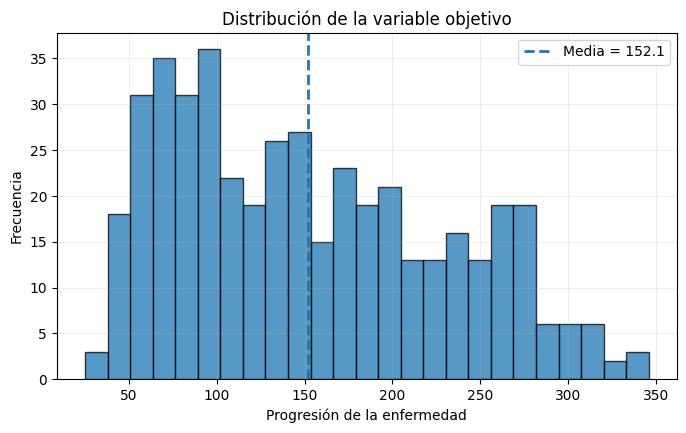

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df[target_name], bins=25, edgecolor='black', alpha=0.75)
ax.axvline(df[target_name].mean(), linestyle='--', linewidth=2, label=f"Media = {df[target_name].mean():.1f}")
ax.set_xlabel('Progresión de la enfermedad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de la variable objetivo')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### 3.2 Boxplots de los predictores

Los boxplots ayudan a comparar escalas, dispersión y posibles observaciones extremas. En otros problemas, diferencias grandes de escala son una señal clara de que debemos estandarizar antes de PCA.

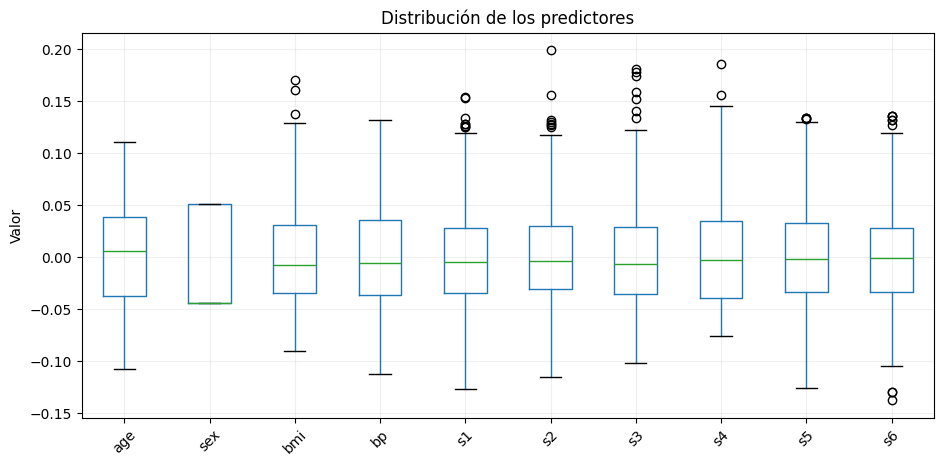

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
df[feature_names].boxplot(ax=ax, rot=45)
ax.set_title('Distribución de los predictores')
ax.set_ylabel('Valor')
ax.grid(alpha=0.2)
plt.show()

### 3.3 Matriz de correlaciones

Si dos predictores están fuertemente correlacionados, contienen información parcialmente redundante. PCA buscará nuevas direcciones que reorganicen esa información.

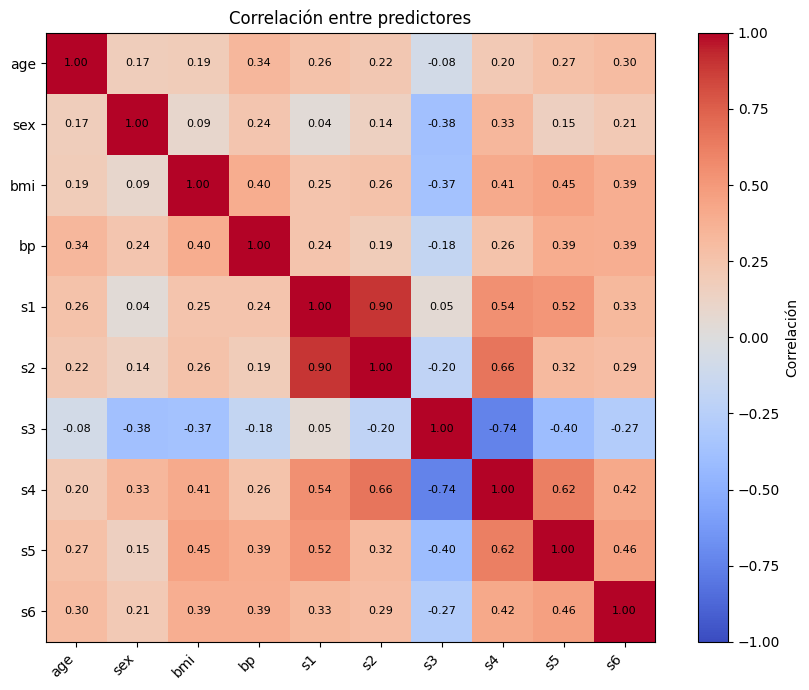

In [ ]:
corr = df[feature_names].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticklabels(feature_names)
ax.set_title('Correlación entre predictores')

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Correlación')
plt.tight_layout()
plt.show()

**Pregunta para discutir:** ¿qué pares de variables parecen contener información redundante? ¿Qué esperarías que haga PCA con esas variables?

### 3.4 Relación de algunos predictores con la respuesta

Estas gráficas usan $y$. PCA **no verá esta información**; PLS sí la utilizará de manera indirecta al construir sus componentes.

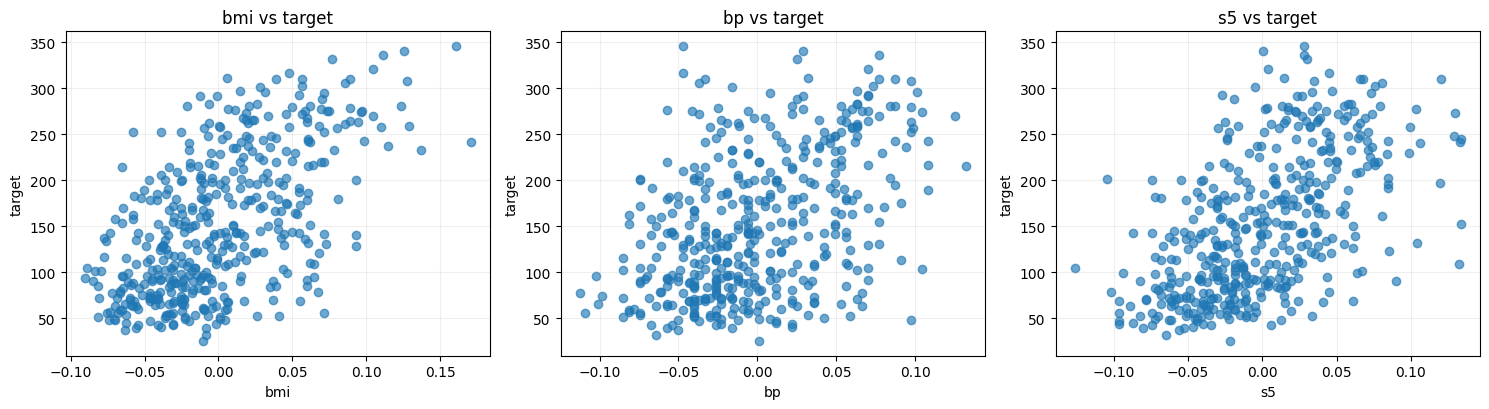

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, var in zip(axes, ['bmi', 'bp', 's5']):
    ax.scatter(df[var], df[target_name], alpha=0.65)
    ax.set_xlabel(var)
    ax.set_ylabel('target')
    ax.set_title(f'{var} vs target')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 3.5 Una mirada multidimensional

Mostramos una matriz de dispersión para algunas variables. No buscamos una conclusión definitiva, sino apreciar que la nube de datos tiene estructura y correlaciones.

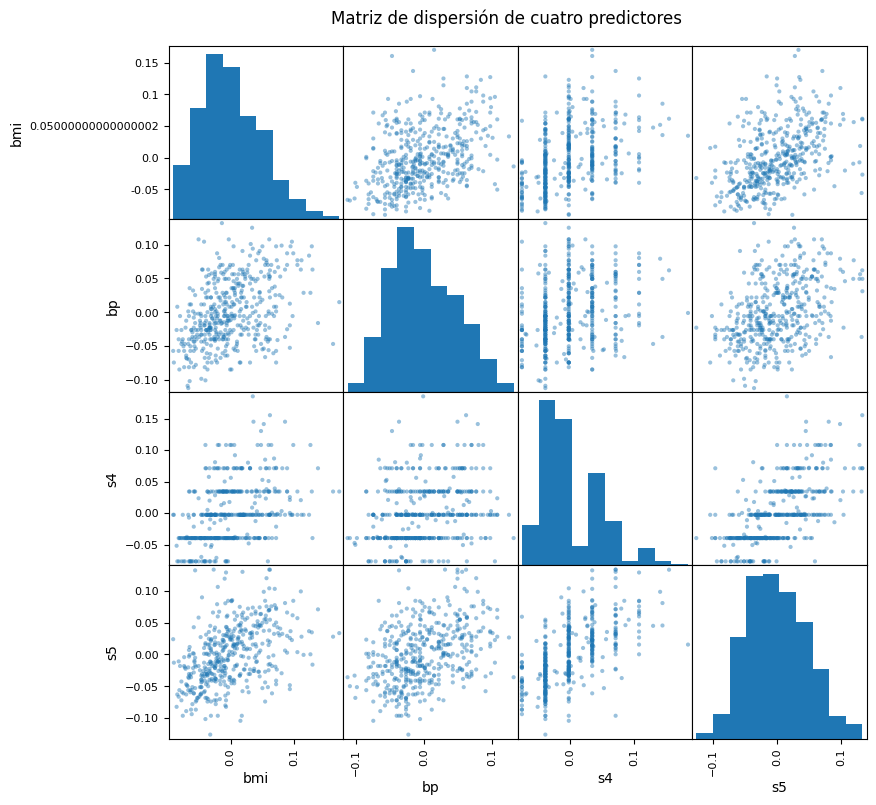

In [ ]:
subset = df[['bmi', 'bp', 's4', 's5']]
axes = scatter_matrix(subset, figsize=(9, 9), diagonal='hist', alpha=0.45)
plt.suptitle('Matriz de dispersión de cuatro predictores', y=0.92)
plt.show()

## 4. Separación train/test y estandarización

La regla importante es:

> El escalador se **ajusta con entrenamiento** y luego se aplica, sin volver a ajustarlo, a entrenamiento y prueba.

Esto evita usar información del conjunto de prueba durante el entrenamiento.

In [ ]:
X = df[feature_names].copy()
y = df[target_name].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print()
print('Media aproximada de X_train escalado:')
print(np.round(X_train_scaled.mean(axis=0), 4))
print()
print('Desviación estándar aproximada:')
print(np.round(X_train_scaled.std(axis=0), 4))

Train: (296, 10)  Test: (146, 10)

Media aproximada de X_train escalado:
[-0.  0.  0.  0. -0.  0.  0.  0. -0. -0.]

Desviación estándar aproximada:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Parte I — PCA

## 5. ¿Qué busca PCA?

Después de centrar/escalar los datos, PCA busca direcciones unitarias $v_j$ que satisfacen

$$
S_X v_j = \lambda_j v_j,
$$

donde $S_X$ es la matriz de covarianza.

- $v_j$: dirección de la componente principal $j$.
- $\lambda_j$: varianza de los datos cuando se proyectan sobre esa dirección.
- Las componentes se ordenan de mayor a menor $\lambda_j$.
- Los vectores $v_j$ son ortogonales entre sí.

Si formamos

$$
A = [v_1\;v_2\;\cdots\;v_p],
$$

entonces las nuevas coordenadas son

$$
Z = X A.
$$

En `scikit-learn`, los vectores $v_j$ aparecen **como filas** de `pca.components_`; por eso, al hacer la proyección manual, debemos usar `pca.components_.T`.

### 5.1 Geometría de una proyección PCA en 2D

Antes de trabajar con las 10 variables del problema real, construyamos una nube bidimensional correlacionada. En 2D sí podemos **ver literalmente** lo que significa proyectar:

1. PCA encuentra el eje PC1 siguiendo la dirección de mayor dispersión de la nube.
2. Cada punto se proyecta perpendicularmente sobre ese eje.
3. Si conservamos únicamente PC1, todos los puntos quedan representados por una sola coordenada.
4. Al reconstruir usando solo PC1, los puntos regresan al plano, pero quedan sobre una recta: la información en la dirección PC2 se perdió.

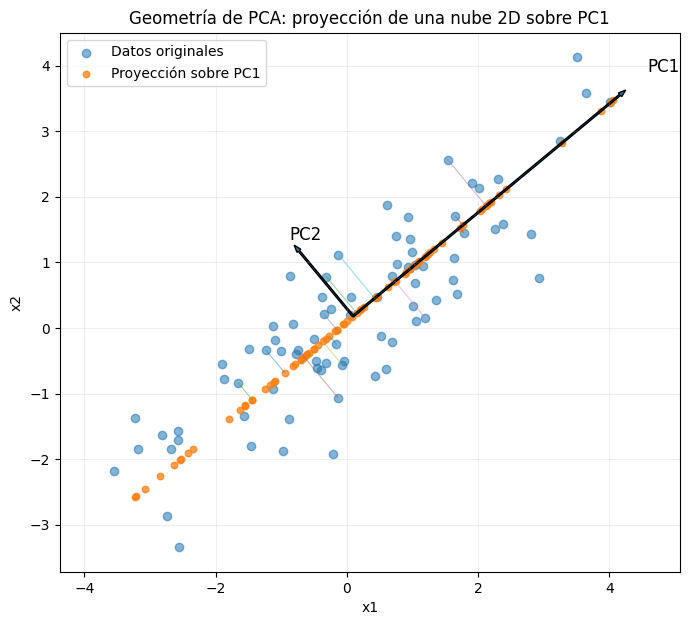

Varianza explicada por PC1: 93.6%
Varianza explicada por PC2: 6.4%


In [ ]:
rng = np.random.default_rng(0)
X_demo = rng.multivariate_normal(
    mean=[0, 0],
    cov=[[3.0, 2.4], [2.4, 2.5]],
    size=80
)

pca_demo = PCA(n_components=2).fit(X_demo)
Z_demo = pca_demo.transform(X_demo)

# Reconstrucción usando solamente PC1
Z_demo_pc1 = Z_demo.copy()
Z_demo_pc1[:, 1] = 0
X_demo_projected = pca_demo.inverse_transform(Z_demo_pc1)

center = pca_demo.mean_
axis1 = pca_demo.components_[0]
axis2 = pca_demo.components_[1]
scale1 = 2.5 * np.sqrt(pca_demo.explained_variance_[0])
scale2 = 2.5 * np.sqrt(pca_demo.explained_variance_[1])

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.55, label='Datos originales')
ax.scatter(X_demo_projected[:, 0], X_demo_projected[:, 1], s=22, alpha=0.75, label='Proyección sobre PC1')

# Segmentos de proyección para una muestra de puntos
for i in range(0, len(X_demo), 5):
    ax.plot(
        [X_demo[i, 0], X_demo_projected[i, 0]],
        [X_demo[i, 1], X_demo_projected[i, 1]],
        linewidth=0.8, alpha=0.45
    )

ax.arrow(center[0], center[1], scale1*axis1[0], scale1*axis1[1],
         width=0.025, length_includes_head=True)
ax.arrow(center[0], center[1], scale2*axis2[0], scale2*axis2[1],
         width=0.025, length_includes_head=True)
ax.text(*(center + 1.08*scale1*axis1), 'PC1', fontsize=12)
ax.text(*(center + 1.08*scale2*axis2), 'PC2', fontsize=12)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Geometría de PCA: proyección de una nube 2D sobre PC1')
ax.axis('equal')
ax.grid(alpha=0.2)
ax.legend()
plt.show()

print('Varianza explicada por PC1:', f'{100*pca_demo.explained_variance_ratio_[0]:.1f}%')
print('Varianza explicada por PC2:', f'{100*pca_demo.explained_variance_ratio_[1]:.1f}%')

## 6. PCA “a mano”: matriz de covarianza, autovalores y autovectores

Esta sección conecta directamente el álgebra lineal con la implementación computacional.

In [ ]:
Sx = np.cov(X_train_scaled, rowvar=False, ddof=1)

eigenvalues, eigenvectors = np.linalg.eigh(Sx)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

manual_ratio = eigenvalues / eigenvalues.sum()
manual_cumulative = np.cumsum(manual_ratio)

pca_manual_table = pd.DataFrame({
    'Componente': np.arange(1, len(feature_names) + 1),
    'Autovalor (varianza)': eigenvalues,
    'Varianza explicada': manual_ratio,
    'Varianza acumulada': manual_cumulative
})

display(pca_manual_table)

,Componente,Autovalor (varianza),Varianza explicada,Varianza acumulada
0,1,4.2237,0.4209,0.4209
1,2,1.4263,0.1421,0.5631
2,3,1.1664,0.1162,0.6793
3,4,0.9439,0.0941,0.7734
4,5,0.6637,0.0661,0.8396
5,6,0.5774,0.0575,0.8971
6,7,0.5139,0.0512,0.9483
7,8,0.4316,0.0430,0.9913
8,9,0.0782,0.0078,0.9991
9,10,0.0088,0.0009,1.0000


### ¿Por qué el autovalor representa varianza?

Si proyectamos los datos sobre una dirección unitaria $v$, la nueva variable es $z=Xv$. Su varianza puede escribirse como

$$
\mathrm{Var}(z)=v^T S_X v.
$$

Maximizar esa cantidad con la restricción $v^Tv=1$ conduce justamente al problema de autovalores. La primera componente escoge la dirección con la mayor varianza posible; la segunda hace lo mismo, pero siendo ortogonal a la primera, y así sucesivamente.

## 7. PCA con `scikit-learn` y verificación algebraica

In [ ]:
p = X_train_scaled.shape[1]
pca = PCA(n_components=p)
pca.fit(X_train_scaled)

print('¿Coinciden los autovalores con sklearn?')
print(np.allclose(eigenvalues, pca.explained_variance_))

print()
print('Primeros autovalores (manual / sklearn):')
print(np.c_[eigenvalues[:5], pca.explained_variance_[:5]])

¿Coinciden los autovalores con sklearn?
True

Primeros autovalores (manual / sklearn):
[[4.2237 4.2237]
 [1.4263 1.4263]
 [1.1664 1.1664]
 [0.9439 0.9439]
 [0.6637 0.6637]]


Los signos de los autovectores pueden cambiar sin alterar el resultado geométrico: $v$ y $-v$ representan el mismo eje. Por eso no conviene comparar autovectores únicamente elemento a elemento sin tener en cuenta esa ambigüedad de signo.

### Verificación de la proyección

Comparamos:

1. `pca.transform(X_train_scaled)`
2. la multiplicación matricial explícita $X A$ con $A=	exttt{components\_.T}$.

In [ ]:
Z_sklearn = pca.transform(X_train_scaled)
A = pca.components_.T
Z_manual = X_train_scaled @ A

print('Máxima diferencia absoluta entre las dos proyecciones:')
print(np.max(np.abs(Z_sklearn - Z_manual)))
print()
print('¿Son numéricamente equivalentes?', np.allclose(Z_sklearn, Z_manual))

Máxima diferencia absoluta entre las dos proyecciones:
5.551115123125783e-17

¿Son numéricamente equivalentes? True


## 8. Varianza explicada: hacerlo bien

Hay tres cantidades distintas que conviene no confundir:

- `explained_variance_`: los autovalores $\lambda_j$ (varianza absoluta de cada componente).
- `explained_variance_ratio_`: fracción de la varianza total explicada por cada componente.
- suma acumulada: porcentaje de varianza que retendríamos usando las primeras $k$ componentes.

In [ ]:
explained = pca.explained_variance_
ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(ratio)

variance_table = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, p + 1)],
    'Autovalor': explained,
    'Varianza explicada (%)': 100 * ratio,
    'Varianza acumulada (%)': 100 * cumulative
})
display(variance_table)

,PC,Autovalor,Varianza explicada (%),Varianza acumulada (%)
0,PC1,4.2237,42.0947,42.0947
1,PC2,1.4263,14.2143,56.3090
2,PC3,1.1664,11.6249,67.9339
3,PC4,0.9439,9.4074,77.3413
4,PC5,0.6637,6.6142,83.9555
5,PC6,0.5774,5.7547,89.7102
6,PC7,0.5139,5.1219,94.8320
7,PC8,0.4316,4.3009,99.1330
8,PC9,0.0782,0.7795,99.9125
9,PC10,0.0088,0.0875,100.0000


### 8.1 Scree plot: varianza de cada componente

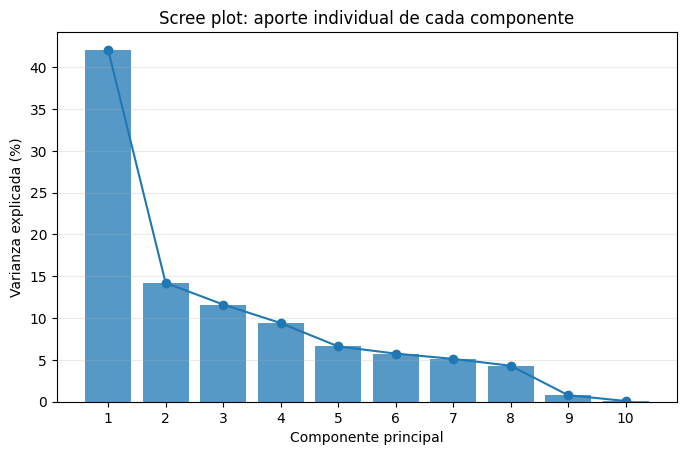

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(np.arange(1, p + 1), 100 * ratio, alpha=0.75)
ax.plot(np.arange(1, p + 1), 100 * ratio, marker='o')
ax.set_xticks(np.arange(1, p + 1))
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Scree plot: aporte individual de cada componente')
ax.grid(axis='y', alpha=0.25)
plt.show()

### 8.2 Varianza acumulada y elección por umbral

Una regla frecuente es conservar suficientes componentes para explicar, por ejemplo, 90% o 95% de la varianza. Esto es una **regla de representación**, no necesariamente una regla óptima para predicción.

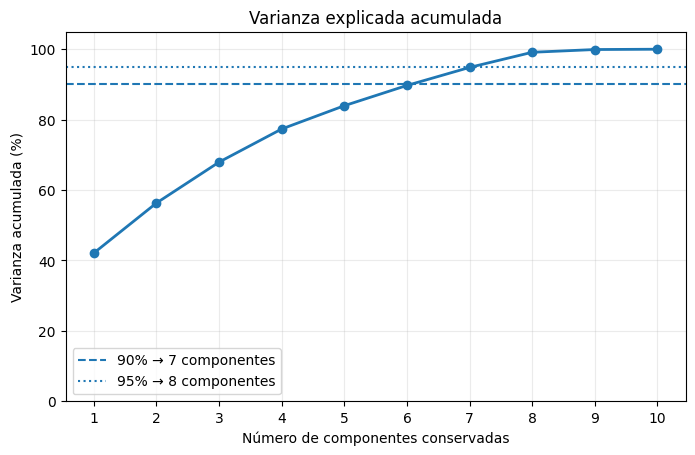

Componentes necesarias para ≥ 90%: 7
Componentes necesarias para ≥ 95%: 8


In [ ]:
n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(np.arange(1, p + 1), 100 * cumulative, marker='o', linewidth=2)
ax.axhline(90, linestyle='--', label=f'90% → {n90} componentes')
ax.axhline(95, linestyle=':', label=f'95% → {n95} componentes')
ax.set_xticks(np.arange(1, p + 1))
ax.set_ylim(0, 105)
ax.set_xlabel('Número de componentes conservadas')
ax.set_ylabel('Varianza acumulada (%)')
ax.set_title('Varianza explicada acumulada')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f'Componentes necesarias para ≥ 90%: {n90}')
print(f'Componentes necesarias para ≥ 95%: {n95}')

**Discusión:** si el 90% de la varianza se alcanza con $k$ componentes, ¿significa eso que esas $k$ componentes son las mejores para predecir $y$? **No necesariamente.** PCA nunca utilizó $y$ para construirlas.

## 9. ¿Cómo se ven las proyecciones?

Cada observación original vive en un espacio de 10 dimensiones. PCA nos permite verla en 2D o 3D usando las primeras componentes.

El color representará el valor de `target`. Esto **no participa en el PCA**: se usa únicamente después, para interpretar si la estructura encontrada en $X$ guarda alguna relación visual con la respuesta.

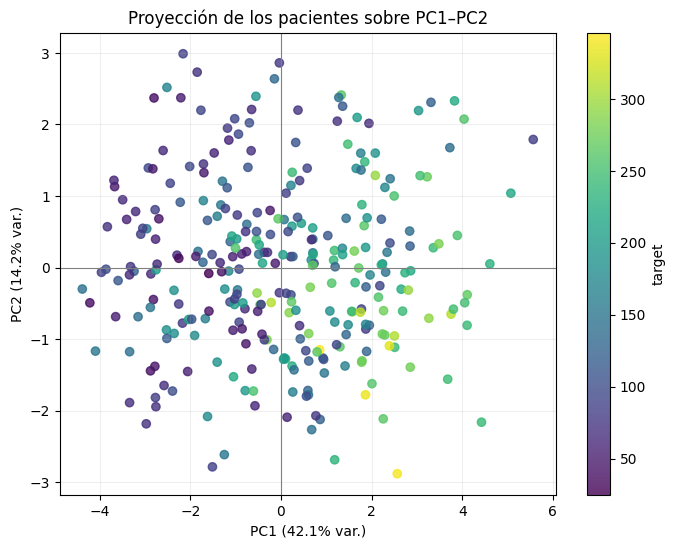

In [ ]:
Z_train = pca.transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_train[:, 0], Z_train[:, 1], c=y_train.to_numpy(), cmap='viridis', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel(f'PC1 ({100*ratio[0]:.1f}% var.)')
ax.set_ylabel(f'PC2 ({100*ratio[1]:.1f}% var.)')
ax.set_title('Proyección de los pacientes sobre PC1–PC2')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('target')
ax.grid(alpha=0.2)
plt.show()

### 9.1 Verificación: las componentes principales están descorrelacionadas

Una de las propiedades centrales de PCA es que las nuevas variables (los *scores*) tienen covarianza cruzada prácticamente nula. Lo comprobamos calculando la matriz de correlación entre las primeras componentes.

> Esto no significa que sean estadísticamente independientes en general; significa que son **linealmente no correlacionadas**.

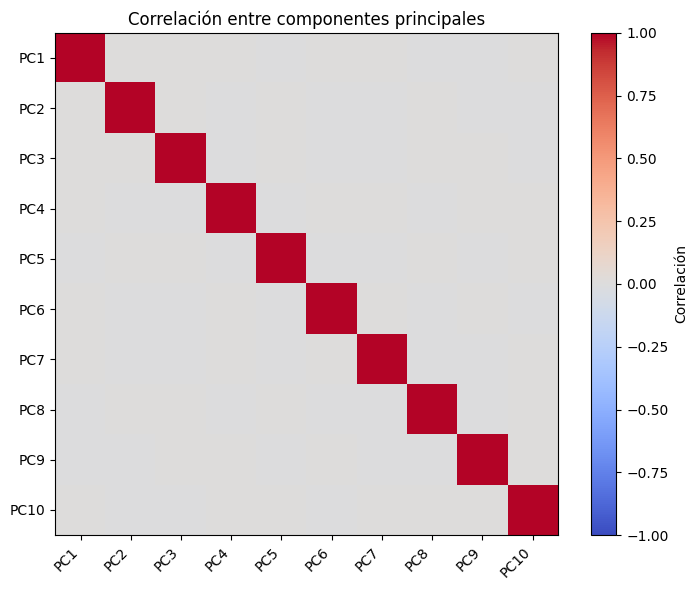

Máxima correlación absoluta fuera de la diagonal: 1.4345211581448002e-14


In [ ]:
pc_corr = np.corrcoef(Z_train, rowvar=False)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(pc_corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(p))
ax.set_yticks(range(p))
ax.set_xticklabels([f'PC{i}' for i in range(1, p+1)], rotation=45, ha='right')
ax.set_yticklabels([f'PC{i}' for i in range(1, p+1)])
ax.set_title('Correlación entre componentes principales')
fig.colorbar(im, ax=ax, label='Correlación')
plt.tight_layout()
plt.show()

off_diag = pc_corr - np.eye(p)
print('Máxima correlación absoluta fuera de la diagonal:', np.abs(off_diag).max())

### 9.2 Proyección tridimensional PC1–PC2–PC3

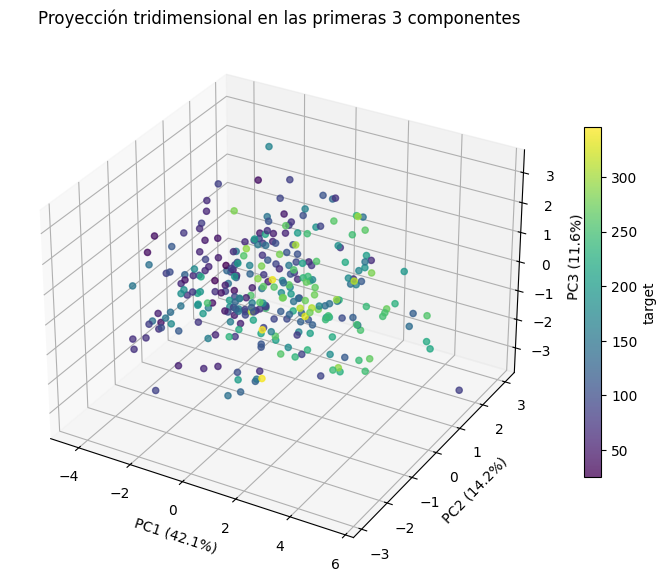

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    Z_train[:, 0], Z_train[:, 1], Z_train[:, 2],
    c=y_train.to_numpy(), cmap='viridis', alpha=0.75
)
ax.set_xlabel(f'PC1 ({100*ratio[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({100*ratio[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({100*ratio[2]:.1f}%)')
ax.set_title('Proyección tridimensional en las primeras 3 componentes')
fig.colorbar(sc, ax=ax, shrink=0.65, label='target')
plt.show()

## 10. Loadings: ¿qué significa cada componente?

Los **scores** son las coordenadas de las observaciones en el nuevo sistema (`Z`). Los **loadings** indican cómo se combinan las variables originales para formar cada componente.

Para PCA de `scikit-learn`, los coeficientes de cada componente están en `pca.components_`.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i}' for i in range(1, p + 1)]
)

display(loadings.iloc[:, :5])

,PC1,PC2,PC3,PC4,PC5
age,0.2232,0.1279,0.4628,0.4613,0.6148
sex,0.1729,-0.4110,-0.1700,0.6674,-0.4185
bmi,0.3020,-0.1187,0.2223,-0.4738,-0.3108
bp,0.2967,-0.1017,0.4872,0.0535,-0.3237
s1,0.3428,0.5599,-0.1553,0.0593,-0.1427
s2,0.3497,0.4109,-0.3660,0.1267,-0.1192
s3,-0.2850,0.5359,0.3042,0.1421,-0.3293
s4,0.4175,-0.1174,-0.3641,-0.0545,0.2295
s5,0.3702,0.0064,0.1251,-0.2671,0.1833
s6,0.3297,-0.0840,0.2670,0.0192,-0.1269


### 10.1 Mapa de calor de los loadings

Valores grandes en valor absoluto indican que una variable participa fuertemente en esa componente. El signo indica la orientación sobre el eje, pero recuerda que el signo completo de una componente puede invertirse sin cambiar la solución.

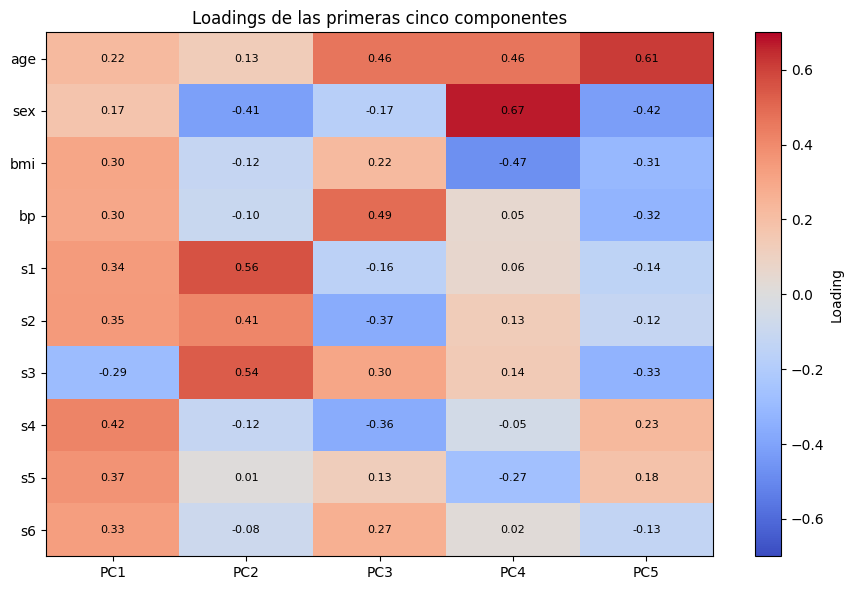

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(loadings.iloc[:, :5], cmap='coolwarm', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_xticks(range(5))
ax.set_xticklabels(loadings.columns[:5])
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.set_title('Loadings de las primeras cinco componentes')

for i in range(len(feature_names)):
    for j in range(5):
        ax.text(j, i, f'{loadings.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Loading')
plt.tight_layout()
plt.show()

### 10.2 Variables más influyentes en PC1 y PC2

In [ ]:
for pc in ['PC1', 'PC2']:
    ranking = loadings[pc].abs().sort_values(ascending=False)
    print(f'Variables con mayor |loading| en {pc}:')
    display(pd.DataFrame({
        'loading': loadings.loc[ranking.index, pc],
        '|loading|': ranking
    }).head(6))

Variables con mayor |loading| en PC1:


,loading,|loading|
s4,0.4175,0.4175
s5,0.3702,0.3702
s2,0.3497,0.3497
s1,0.3428,0.3428
s6,0.3297,0.3297
bmi,0.3020,0.3020


Variables con mayor |loading| en PC2:


,loading,|loading|
s1,0.5599,0.5599
s3,0.5359,0.5359
sex,-0.4110,0.4110
s2,0.4109,0.4109
age,0.1279,0.1279
bmi,-0.1187,0.1187


## 11. Biplot simplificado: observaciones + direcciones de variables

El biplot combina dos ideas:

- puntos: observaciones proyectadas en PC1–PC2;
- flechas: dirección en la que aumenta cada variable original.

Para no saturar la gráfica, usamos una versión reescalada de los scores.

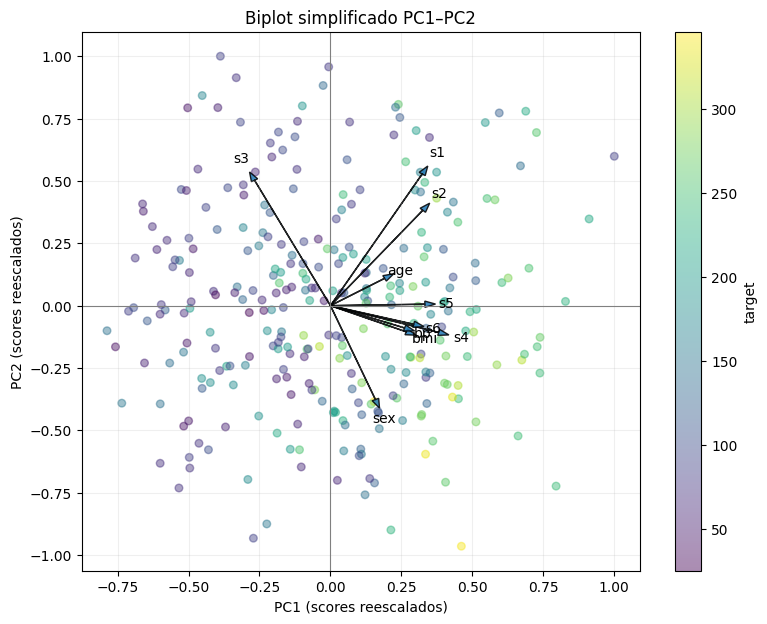

In [ ]:
score_2d = Z_train[:, :2]
score_scaled = score_2d / np.max(np.abs(score_2d), axis=0)
loading_2d = pca.components_[:2].T

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    score_scaled[:, 0], score_scaled[:, 1],
    c=y_train.to_numpy(), cmap='viridis', alpha=0.45, s=30
)

for i, var in enumerate(feature_names):
    x, yy = loading_2d[i, 0], loading_2d[i, 1]
    ax.arrow(0, 0, x, yy, head_width=0.025, length_includes_head=True, alpha=0.85)
    ax.text(1.10*x, 1.10*yy, var, fontsize=10, ha='center', va='center')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('PC1 (scores reescalados)')
ax.set_ylabel('PC2 (scores reescalados)')
ax.set_title('Biplot simplificado PC1–PC2')
fig.colorbar(sc, ax=ax, label='target')
ax.grid(alpha=0.2)
plt.show()

**Preguntas para la clase:**

1. ¿Qué variables apuntan en direcciones parecidas? Eso sugiere asociación positiva.
2. ¿Qué variables apuntan aproximadamente en direcciones opuestas?
3. ¿Qué variables tienen flechas largas en el plano PC1–PC2? Son las mejor representadas por estas dos componentes.
4. ¿Se observa algún gradiente del `target` a lo largo de PC1 o PC2?

## 12. ¿Qué perdemos al reducir dimensión? Error de reconstrucción

PCA puede comprimir los datos y luego aproximar de nuevo las variables originales. Si usamos pocas componentes, habrá pérdida de información.

Para $k=1,2,\ldots,p$ mediremos el error cuadrático medio entre los datos escalados y su reconstrucción.

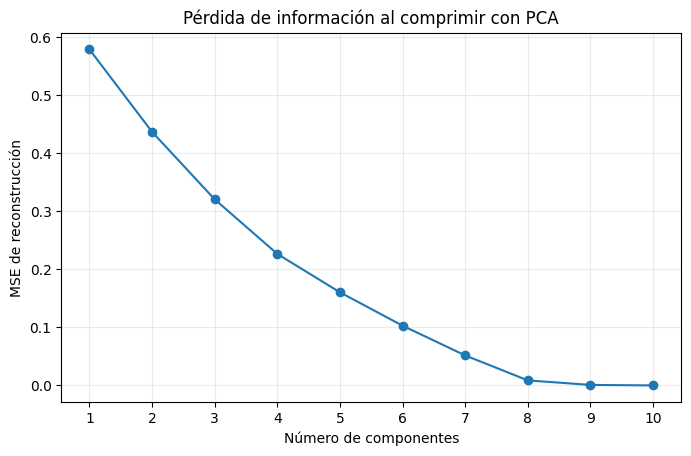

In [ ]:
reconstruction_mse = []
for k in range(1, p + 1):
    pca_k = PCA(n_components=k)
    Zk = pca_k.fit_transform(X_train_scaled)
    X_reconstructed = pca_k.inverse_transform(Zk)
    reconstruction_mse.append(np.mean((X_train_scaled - X_reconstructed)**2))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(range(1, p + 1), reconstruction_mse, marker='o')
ax.set_xticks(range(1, p + 1))
ax.set_xlabel('Número de componentes')
ax.set_ylabel('MSE de reconstrucción')
ax.set_title('Pérdida de información al comprimir con PCA')
ax.grid(alpha=0.25)
plt.show()

# Parte II — PCR: regresión sobre componentes principales

PCA por sí solo **no es un modelo de regresión**. PCR (Principal Component Regression) hace dos pasos:

1. transforma $X$ con PCA;
2. ajusta una regresión lineal usando las primeras $k$ componentes.

Aquí aparece una pregunta crucial: **¿cuántas componentes usar para predecir?**

En vez de escogerlas únicamente con la varianza explicada, podemos evaluar el error de predicción mediante validación cruzada.

## 13. Selección del número de componentes de PCR por validación cruzada

Usamos un `Pipeline` para que el escalado y PCA se ajusten dentro de cada fold de validación, evitando fuga de información (*data leakage*).

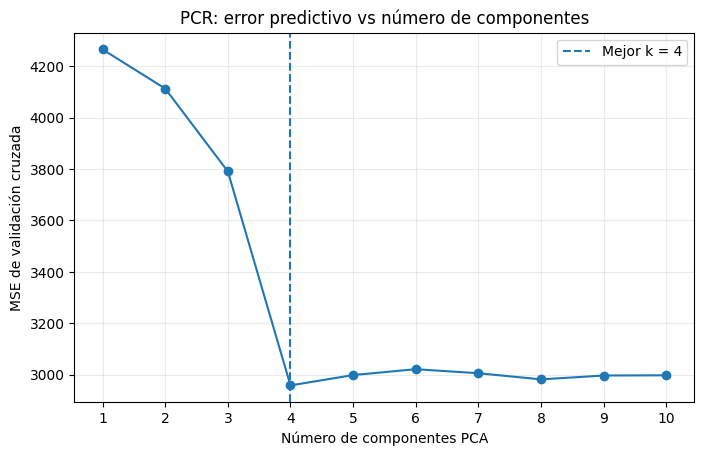

Mejor número de componentes para PCR según CV: 4
Número para 90% de varianza: 7


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ks = np.arange(1, p + 1)
pcr_cv_mse = []

for k in ks:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k)),
        ('reg', LinearRegression())
    ])
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='neg_mean_squared_error'
    )
    pcr_cv_mse.append(-scores.mean())

best_k_pcr = int(ks[np.argmin(pcr_cv_mse)])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ks, pcr_cv_mse, marker='o')
ax.axvline(best_k_pcr, linestyle='--', label=f'Mejor k = {best_k_pcr}')
ax.set_xticks(ks)
ax.set_xlabel('Número de componentes PCA')
ax.set_ylabel('MSE de validación cruzada')
ax.set_title('PCR: error predictivo vs número de componentes')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f'Mejor número de componentes para PCR según CV: {best_k_pcr}')
print(f'Número para 90% de varianza: {n90}')

**Punto didáctico importante:** el número de componentes que conserva mucha varianza de $X$ puede ser diferente del número que minimiza el error al predecir $y$.

In [ ]:
pcr_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_k_pcr)),
    ('reg', LinearRegression())
])
pcr_best.fit(X_train, y_train)
y_pred_pcr = pcr_best.predict(X_test)

# Parte III — PLS

## 14. Idea de PLS

PCA construye componentes que explican varianza de $X$:

$$
X \longrightarrow \text{componentes con gran varianza}.
$$

PLS intenta construir componentes que además estén relacionadas con $y$:

$$
(X,y) \longrightarrow \text{componentes útiles para explicar/predicir } y.
$$

Por eso PLS es un método **supervisado** de construcción de variables latentes.

## 15. Selección del número de componentes PLS por validación cruzada

Para comparar de manera justa, también elegiremos el número de componentes PLS mediante validación cruzada.

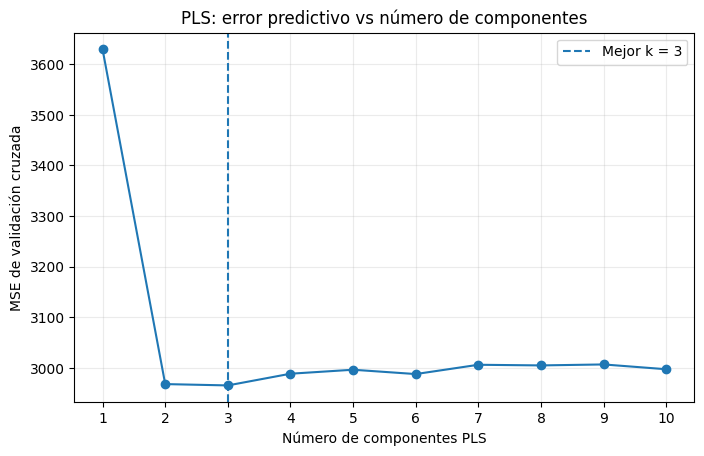

Mejor número de componentes para PLS según CV: 3


In [ ]:
pls_cv_mse = []

for k in ks:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pls', PLSRegression(n_components=k, scale=False))
    ])
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='neg_mean_squared_error'
    )
    pls_cv_mse.append(-scores.mean())

best_k_pls = int(ks[np.argmin(pls_cv_mse)])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ks, pls_cv_mse, marker='o')
ax.axvline(best_k_pls, linestyle='--', label=f'Mejor k = {best_k_pls}')
ax.set_xticks(ks)
ax.set_xlabel('Número de componentes PLS')
ax.set_ylabel('MSE de validación cruzada')
ax.set_title('PLS: error predictivo vs número de componentes')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f'Mejor número de componentes para PLS según CV: {best_k_pls}')

### 15.1 PCR y PLS en una misma gráfica

Esta comparación permite discutir que **PCA optimiza representación de $X$**, mientras PLS construye componentes mirando la relación con la respuesta.

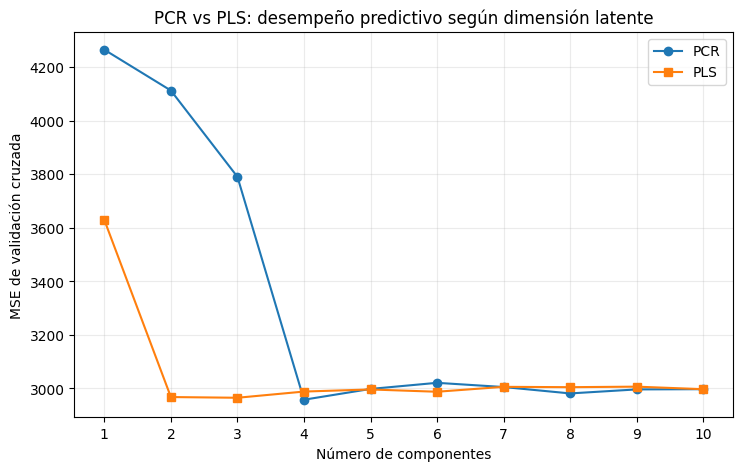

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(ks, pcr_cv_mse, marker='o', label='PCR')
ax.plot(ks, pls_cv_mse, marker='s', label='PLS')
ax.set_xticks(ks)
ax.set_xlabel('Número de componentes')
ax.set_ylabel('MSE de validación cruzada')
ax.set_title('PCR vs PLS: desempeño predictivo según dimensión latente')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 16. Visualización de los scores de PLS

Para visualizar las variables latentes de PLS, ajustamos el escalador y el modelo sobre entrenamiento. Si el mejor modelo tuviera una sola componente, usamos dos componentes únicamente para esta gráfica didáctica.

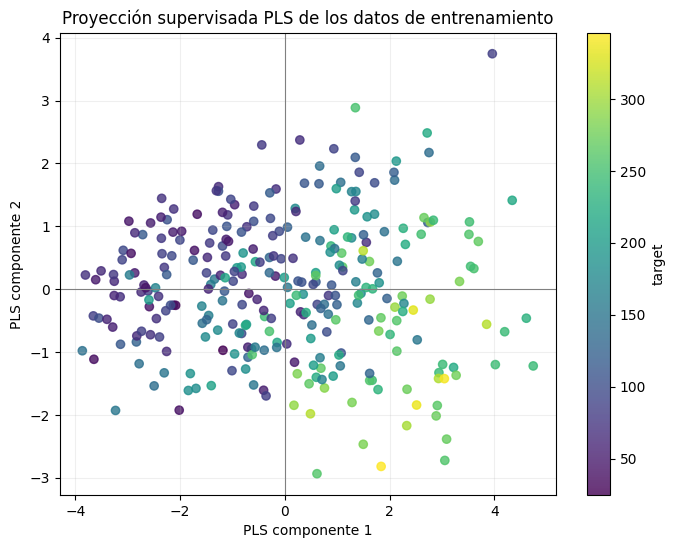

In [ ]:
scaler_pls = StandardScaler()
X_train_pls_scaled = scaler_pls.fit_transform(X_train)
X_test_pls_scaled = scaler_pls.transform(X_test)

n_vis_pls = max(2, best_k_pls)
pls_vis = PLSRegression(n_components=n_vis_pls, scale=False)
pls_vis.fit(X_train_pls_scaled, y_train)
T_train = pls_vis.x_scores_

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(T_train[:, 0], T_train[:, 1], c=y_train.to_numpy(), cmap='viridis', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('PLS componente 1')
ax.set_ylabel('PLS componente 2')
ax.set_title('Proyección supervisada PLS de los datos de entrenamiento')
fig.colorbar(sc, ax=ax, label='target')
ax.grid(alpha=0.2)
plt.show()

### PCA vs PLS: comparación visual de los primeros dos ejes

El color vuelve a representar `target`. Busca si el gradiente de color parece organizarse mejor en una representación que en la otra.

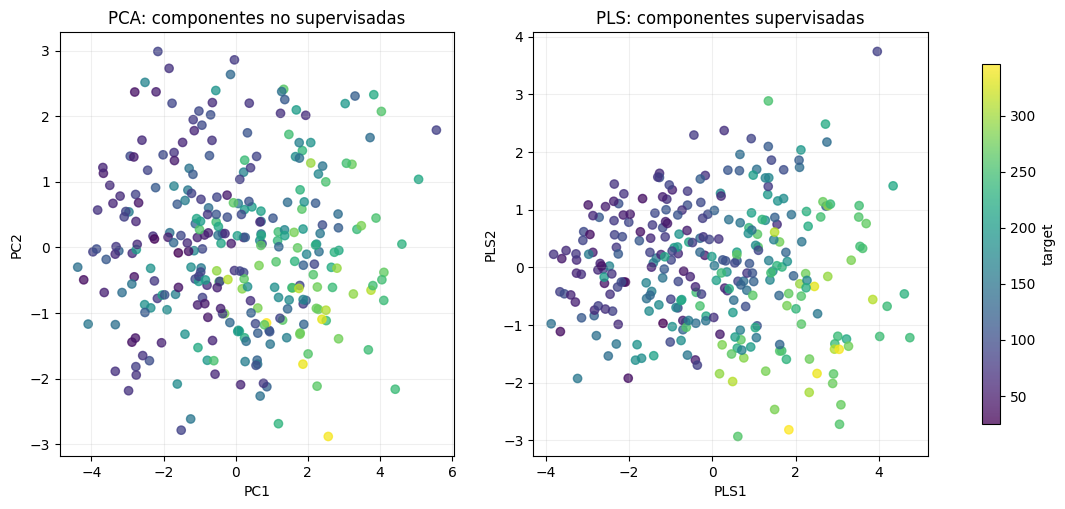

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc1 = axes[0].scatter(Z_train[:, 0], Z_train[:, 1], c=y_train.to_numpy(), cmap='viridis', alpha=0.75)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA: componentes no supervisadas')
axes[0].grid(alpha=0.2)

sc2 = axes[1].scatter(T_train[:, 0], T_train[:, 1], c=y_train.to_numpy(), cmap='viridis', alpha=0.75)
axes[1].set_xlabel('PLS1')
axes[1].set_ylabel('PLS2')
axes[1].set_title('PLS: componentes supervisadas')
axes[1].grid(alpha=0.2)

fig.colorbar(sc2, ax=axes, label='target', shrink=0.85)
plt.show()

## 17. Ajuste final de PLS

In [ ]:
pls_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pls', PLSRegression(n_components=best_k_pls, scale=False))
])
pls_best.fit(X_train, y_train)
y_pred_pls = np.asarray(pls_best.predict(X_test)).reshape(-1)

# Parte IV — Comparación de modelos

Compararemos:

1. **Regresión lineal** con todos los predictores estandarizados (baseline).
2. **PCR** con el número de componentes elegido por validación cruzada.
3. **PLS** con el número de componentes elegido por validación cruzada.

Usaremos MSE, RMSE y $R^2$.

In [ ]:
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
baseline.fit(X_train, y_train)
y_pred_lr = baseline.predict(X_test)

predictions = {
    'Regresión lineal': y_pred_lr,
    f'PCR ({best_k_pcr} comp.)': y_pred_pcr,
    f'PLS ({best_k_pls} comp.)': y_pred_pls
}

rows = []
for name, pred in predictions.items():
    mse = mean_squared_error(y_test, pred)
    rows.append({
        'Modelo': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, pred)
    })

results = pd.DataFrame(rows).sort_values('MSE').reset_index(drop=True)
display(results)

,Modelo,MSE,RMSE,R2
0,PCR (4 comp.),3056.5263,55.2859,0.4198
1,PLS (3 comp.),3118.7738,55.8460,0.4080
2,Regresión lineal,3143.5361,56.0672,0.4033


### 18.1 Comparación gráfica del MSE

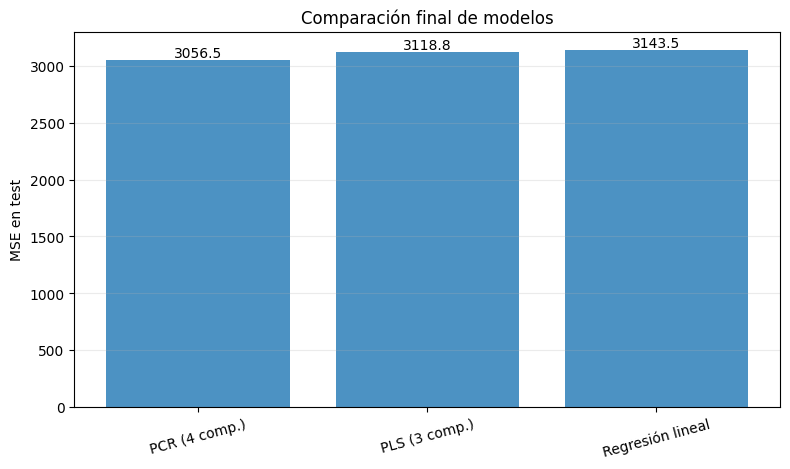

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(results['Modelo'], results['MSE'], alpha=0.8)
ax.set_ylabel('MSE en test')
ax.set_title('Comparación final de modelos')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.25)

for bar, value in zip(bars, results['MSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.1f}',
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 18.2 Predicción vs valor real

Un modelo ideal produciría puntos cercanos a la diagonal $\hat y=y$.

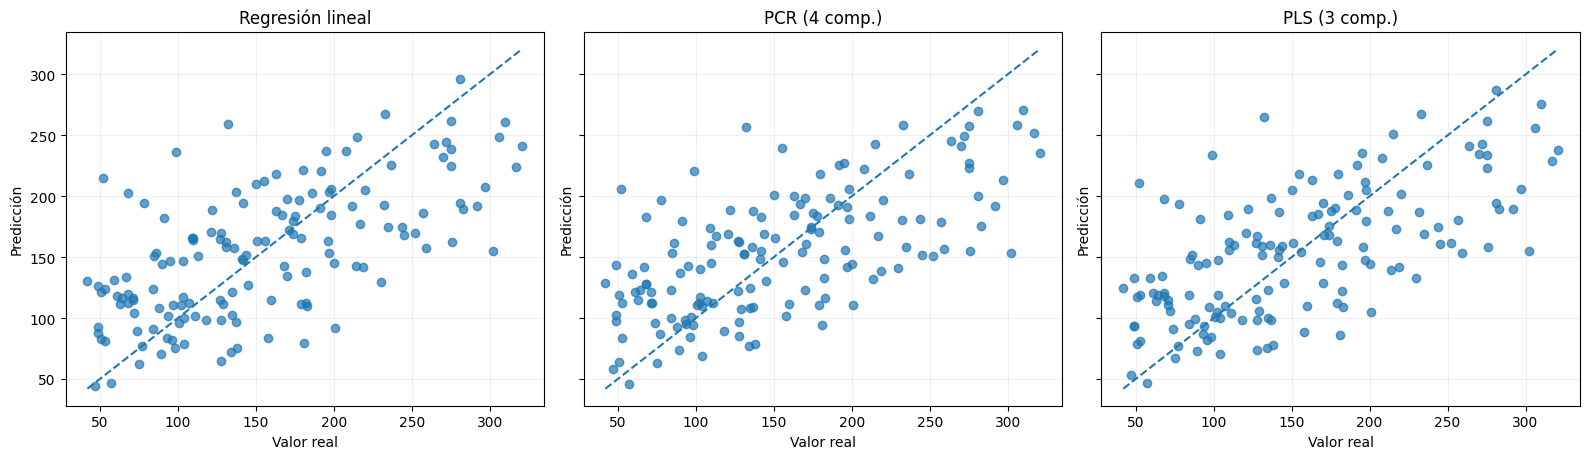

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), sharex=True, sharey=True)

all_vals = np.r_[y_test.to_numpy(), y_pred_lr, y_pred_pcr, y_pred_pls]
lo, hi = all_vals.min(), all_vals.max()

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.7)
    ax.plot([lo, hi], [lo, hi], linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predicción')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 18.3 Residuos

Los residuos $e_i=y_i-\hat y_i$ deberían fluctuar alrededor de cero sin patrones sistemáticos evidentes.

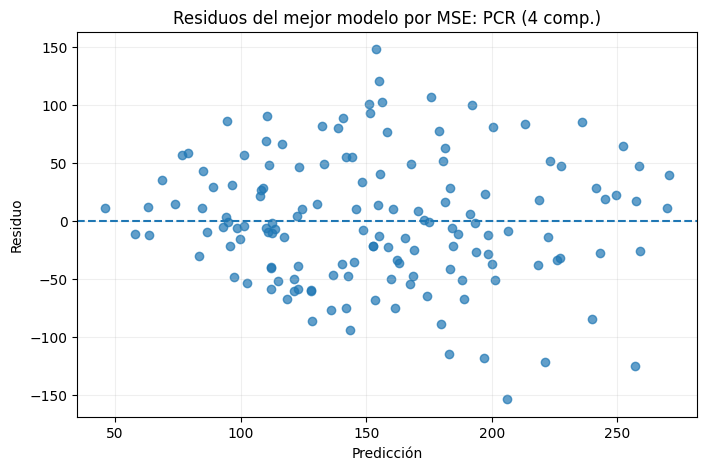

In [ ]:
best_model_name = results.iloc[0]['Modelo']
best_pred = predictions[best_model_name]
residuals = y_test.to_numpy() - best_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_pred, residuals, alpha=0.7)
ax.axhline(0, linestyle='--')
ax.set_xlabel('Predicción')
ax.set_ylabel('Residuo')
ax.set_title(f'Residuos del mejor modelo por MSE: {best_model_name}')
ax.grid(alpha=0.2)
plt.show()

# 19. Síntesis conceptual

| Aspecto | PCA / PCR | PLS |
|---|---|---|
| Usa $y$ para construir componentes | No | Sí |
| Objetivo de las componentes | Maximizar varianza de $X$ | Capturar estructura de $X$ útil para $y$ |
| Componentes ortogonales | Sí, por construcción | Variables latentes construidas secuencialmente |
| Puede visualizarse en 2D/3D | Sí | Sí |
| Elegir componentes por varianza | Tiene interpretación directa | No es el criterio principal |
| Elegir componentes para predecir | Mejor mediante CV | Mejor mediante CV |

### Mensajes que deberían quedar claros

1. **PCA es una rotación/proyección del espacio de predictores.**
2. Los autovalores indican cuánta varianza captura cada dirección.
3. La varianza acumulada sirve para medir **compresión**, no garantiza mejor predicción.
4. Los *scores* describen dónde quedan las observaciones en el espacio reducido.
5. Los *loadings* describen cómo se construyen las componentes a partir de las variables originales.
6. PCR hace regresión después de PCA.
7. PLS usa la respuesta durante la construcción de las variables latentes.
8. Para fines predictivos, el número de componentes debe validarse con datos no usados para ajustar el modelo.

# 20. Actividades para los estudiantes

### Actividad A — Umbral de varianza
Cambia el umbral del 90% al 80%, 95% y 99%. ¿Cuántas componentes requiere cada caso? ¿Cómo cambia el error de reconstrucción?

### Actividad B — Interpretación de loadings
Escoge PC1, PC2 y PC3. Para cada una, identifica las tres variables con mayor `|loading|` y redacta una interpretación cualitativa.

### Actividad C — Geometría
Toma dos pacientes del conjunto de entrenamiento. Compara sus coordenadas originales escaladas y sus coordenadas en PC1–PC2. ¿Qué información se conserva y cuál se pierde?

### Actividad D — Predicción
Compara el $k$ que explica 90% de la varianza con el $k$ que minimiza el MSE de validación cruzada para PCR. Explica por qué no tienen que coincidir.

### Actividad E — PCA vs PLS
Observa las gráficas PC1–PC2 y PLS1–PLS2 coloreadas por `target`. ¿En cuál parece existir un gradiente de respuesta más claro? Relaciona tu respuesta con el hecho de que PLS sí utiliza $y$.

### Actividad F — Cambio de variables
Elimina uno de los predictores fuertemente correlacionados y repite PCA. ¿Cómo cambian la varianza explicada y los loadings?

## Cierre

La idea más importante de esta práctica es separar tres preguntas diferentes:

- **¿Cómo está estructurada la variabilidad de $X$?** → PCA.
- **¿Cuántas dimensiones necesito para representar bien $X$?** → varianza acumulada y reconstrucción.
- **¿Cuántas dimensiones necesito para predecir bien $y$?** → validación cruzada, PCR y PLS.

Confundir estas tres preguntas suele conducir a una selección incorrecta del número de componentes.